ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

[1] Загрузка данных...
Using Colab cache for faster access to the 'steam-store-games' dataset.
Загружен steam.csv: 27075 строк, 18 колонок

[2] Очистка данных...
После очистки: 27075 строк, 397 колонок

[3] Разделение данных на train (80%) и test (20%)...
Train: 21660 игр
Test: 5415 игр

[4] Обучение модели на train...
Модель обучена на 21660 играх
Эмбеддинги: (21660, 29)

[5] Преобразование test с использованием обученной модели...
Test преобразован: (5415, 29)

[6] Вычисление матрицы сходства для train...
Матрица сходства train: (21660, 21660)

[7] Расчёт метрик качества...

Результаты оценки на тестовой выборке (200 игр):
   Precision@5: 0.727
   Средний коэффициент сходства: 0.926

   Это значит, что в среднем 72.7% рекомендаций имеют общий жанр с исходной игрой.

[8] Визуализация результатов...


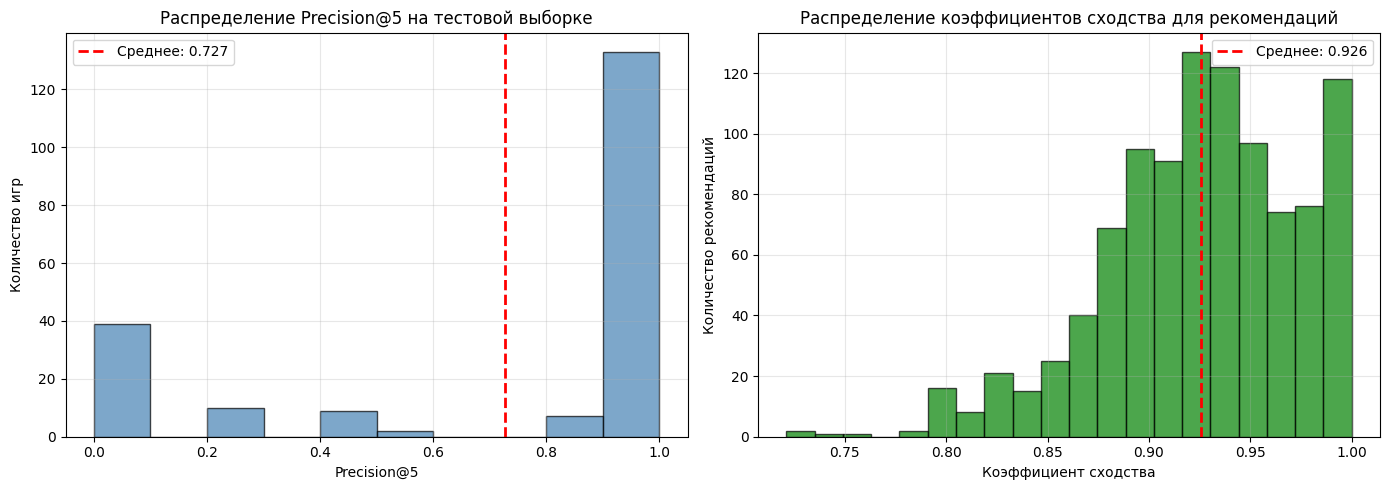


[9] Примеры рекомендаций (test → train):

Игра 'Counter-Strike' не найдена в test-выборке

'Stardew Valley':
   1. Cute Cats PuZZles (сходство: 0.977)
   2. Dinoku (сходство: 0.977)
   3. Sky Dodge (сходство: 0.976)

'DOOM':
   1. Civilization IV®: Warlords (сходство: 0.969)
   2. Civil War: Gettysburg (сходство: 0.926)
   3. Tank Battle: Pacific (сходство: 0.926)

Игра 'Portal 2' не найдена в test-выборке

ИТОГИ ОЦЕНКИ НА ТЕСТОВОЙ ВЫБОРКЕ
Train: 21660 игр
Test: 5415 игр
Precision@5: 0.727
   (72.7% рекомендаций имеют общий жанр)
Средний коэффициент сходства: 0.926

Качество рекомендаций хорошее (Precision@5 > 0.5)

Результаты сохранены в test_results.csv


In [2]:
# ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ (Train/Test Split)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import os

print("="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

print("\n[1] Загрузка данных...")

import kagglehub
path = kagglehub.dataset_download("nikdavis/steam-store-games")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if 'steam.csv' in csv_files:
    csv_path = os.path.join(path, 'steam.csv')
    df_raw = pd.read_csv(csv_path)
    print(f"Загружен steam.csv: {df_raw.shape[0]} строк, {df_raw.shape[1]} колонок")
else:
    for f in csv_files:
        test_df = pd.read_csv(os.path.join(path, f))
        if 'developer' in test_df.columns and 'genres' in test_df.columns:
            df_raw = test_df
            print(f"Загружен {f}: {df_raw.shape[0]} строк, {df_raw.shape[1]} колонок")
            break

print("\n[2] Очистка данных...")

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

def clean_data(df):
    # Очистка
    df['developer'] = df['developer'].fillna('Unknown')
    df['publisher'] = df['publisher'].fillna('Unknown')

    # Новые признаки
    df['release_year'] = df['release_date'].str[:4].astype(int)
    df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
    df['rating_ratio'] = df['positive_ratings'] / (df['total_ratings'] + 1)

    def parse_owners(x):
        try:
            low, high = x.split('-')
            return (int(low.replace(',', '')) + int(high.replace(',', ''))) / 2
        except:
            return None
    df['owners_mean'] = df['owners'].apply(parse_owners)

    # Бинарные признаки
    def make_binary(df, col, prefix):
        mlb = MultiLabelBinarizer()
        binary = mlb.fit_transform(df[col].str.lower().str.split(';'))
        return pd.DataFrame(binary, columns=[f'{prefix}_{c}' for c in mlb.classes_])

    genres_df = make_binary(df, 'genres', 'genre')
    categories_df = make_binary(df, 'categories', 'cat')
    tags_df = make_binary(df, 'steamspy_tags', 'tag')
    platforms_df = make_binary(df, 'platforms', 'platform')

    cols_to_remove = set()
    cols_to_remove.update([col.replace('genre_', '') for col in genres_df.columns])
    cols_to_remove.update([col.replace('cat_', '') for col in categories_df.columns])
    cols_to_remove.update([col.replace('platform_', '') for col in platforms_df.columns])
    tags_clean = tags_df.drop(
        columns=[f'tag_{val}' for val in cols_to_remove if f'tag_{val}' in tags_df.columns],
        errors='ignore'
    )

    # Текстовые признаки
    df['genres_text'] = df['genres'].str.lower().str.replace(';', ' ', regex=False)
    df['categories_text'] = df['categories'].str.lower().str.replace(';', ' ', regex=False)
    df['platforms_text'] = df['platforms'].str.lower().str.replace(';', ' ', regex=False)

    all_genres = set()
    for val in df['genres'].dropna():
        if isinstance(val, str):
            for v in val.split(';'):
                all_genres.add(v.strip().lower())

    all_categories = set()
    for val in df['categories'].dropna():
        if isinstance(val, str):
            for v in val.split(';'):
                all_categories.add(v.strip().lower())

    def clean_tags_text(tags_str):
        if not isinstance(tags_str, str):
            return ''
        tags = [t.strip().lower() for t in tags_str.split(';')]
        filtered = [t for t in tags if t not in all_genres and t not in all_categories]
        return ' '.join(filtered)

    df['tags_text_clean'] = df['steamspy_tags'].apply(clean_tags_text)

    # Кодирование developer
    le = LabelEncoder()
    df['developer_encoded'] = le.fit_transform(df['developer'])

    # Объединяем
    df_onehot = pd.concat([genres_df, categories_df, tags_clean, platforms_df], axis=1)
    df = pd.concat([df, df_onehot], axis=1)

    return df

df = clean_data(df_raw.copy())
print(f"После очистки: {df.shape[0]} строк, {df.shape[1]} колонок")

print("\n[3] Разделение данных на train (80%) и test (20%)...")

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train: {len(train_df)} игр")
print(f"Test: {len(test_df)} игр")

print("\n[4] Обучение модели на train...")

binary_cols = [col for col in train_df.columns if col.startswith(('genre_', 'cat_', 'tag_', 'platform_'))]
numeric_cols = ['rating_ratio', 'positive_ratings', 'negative_ratings', 'price', 'developer_encoded']

scaler_train = StandardScaler()
numeric_scaled_train = scaler_train.fit_transform(train_df[numeric_cols])
df_numeric_train = pd.DataFrame(numeric_scaled_train, columns=numeric_cols, index=train_df.index)
feature_matrix_train = pd.concat([df_numeric_train, train_df[binary_cols]], axis=1)

svd_train = TruncatedSVD(n_components=29, random_state=42)
train_embeddings = svd_train.fit_transform(feature_matrix_train.values)

print(f"Модель обучена на {len(train_df)} играх")
print(f"Эмбеддинги: {train_embeddings.shape}")

print("\n[5] Преобразование test с использованием обученной модели...")

numeric_scaled_test = scaler_train.transform(test_df[numeric_cols])
df_numeric_test = pd.DataFrame(numeric_scaled_test, columns=numeric_cols, index=test_df.index)
feature_matrix_test = pd.concat([df_numeric_test, test_df[binary_cols]], axis=1)

test_embeddings = svd_train.transform(feature_matrix_test.values)

print(f"Test преобразован: {test_embeddings.shape}")
print("\n[6] Вычисление матрицы сходства для train...")

train_similarity = cosine_similarity(train_embeddings)
print(f"Матрица сходства train: {train_similarity.shape}")

def get_recommendations_for_test(game_name, train_df, test_df, train_similarity, n=5):
    """Находит для test-игры похожие train-игры"""
    matches = test_df[test_df['name'].str.lower() == game_name.lower()]
    if matches.empty:
        matches = test_df[test_df['name'].str.lower().str.contains(game_name.lower(), na=False)]
        if matches.empty:
            return None

    test_idx = matches.index[0]
    test_pos = test_df.index.get_loc(test_idx)
    sim_row = train_similarity[test_pos % len(train_df)]
    top_indices = np.argsort(sim_row)[::-1][1:n+1]
    top_scores = sim_row[top_indices]
    top_games = train_df.iloc[top_indices]['name'].values

    return top_games, top_scores

print("\n[7] Расчёт метрик качества...")

precision_scores = []
similarity_scores = []

sample_test = test_df.head(200)

for idx, row in sample_test.iterrows():
    game_name = row['name']
    game_genres = set(str(row['genres']).split(';')) if pd.notna(row['genres']) else set()

    recs = get_recommendations_for_test(game_name, train_df, test_df, train_similarity, n=5)
    if recs is None:
        continue

    rec_games, rec_scores = recs
    similarity_scores.extend(rec_scores)

    relevant_count = 0
    for rec_game in rec_games:
        rec_row = train_df[train_df['name'] == rec_game]
        if not rec_row.empty:
            rec_genres = set(str(rec_row.iloc[0]['genres']).split(';')) if pd.notna(rec_row.iloc[0]['genres']) else set()
            if len(game_genres.intersection(rec_genres)) > 0:
                relevant_count += 1

    precision = relevant_count / 5
    precision_scores.append(precision)

avg_precision = np.mean(precision_scores) if precision_scores else 0
avg_similarity = np.mean(similarity_scores) if similarity_scores else 0

print(f"\nРезультаты оценки на тестовой выборке (200 игр):")
print(f"   Precision@5: {avg_precision:.3f}")
print(f"   Средний коэффициент сходства: {avg_similarity:.3f}")
print(f"\n   Это значит, что в среднем {avg_precision*100:.1f}% рекомендаций имеют общий жанр с исходной игрой.")

print("\n[8] Визуализация результатов...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Гистограмма Precision@5
ax1 = axes[0]
if precision_scores:
    ax1.hist(precision_scores, bins=10, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(x=avg_precision, color='red', linestyle='--', linewidth=2, label=f'Среднее: {avg_precision:.3f}')
    ax1.set_xlabel('Precision@5')
    ax1.set_ylabel('Количество игр')
    ax1.set_title('Распределение Precision@5 на тестовой выборке')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# График 2: Гистограмма коэффициентов сходства
ax2 = axes[1]
if similarity_scores:
    ax2.hist(similarity_scores, bins=20, color='green', edgecolor='black', alpha=0.7)
    ax2.axvline(x=avg_similarity, color='red', linestyle='--', linewidth=2,
                label=f'Среднее: {avg_similarity:.3f}')
    ax2.set_xlabel('Коэффициент сходства')
    ax2.set_ylabel('Количество рекомендаций')
    ax2.set_title('Распределение коэффициентов сходства для рекомендаций')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('train_test_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[9] Примеры рекомендаций (test → train):")

test_examples = ['Counter-Strike', 'Stardew Valley', 'DOOM', 'Portal 2']
for game in test_examples:
    recs = get_recommendations_for_test(game, train_df, test_df, train_similarity, n=3)
    if recs is not None:
        rec_games, rec_scores = recs
        print(f"\n'{game}':")
        for i, (g, s) in enumerate(zip(rec_games, rec_scores)):
            print(f"   {i+1}. {g} (сходство: {s:.3f})")
    else:
        print(f"\nИгра '{game}' не найдена в test-выборке")

print("\n" + "="*60)
print("ИТОГИ ОЦЕНКИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)
print(f"Train: {len(train_df)} игр")
print(f"Test: {len(test_df)} игр")
print(f"Precision@5: {avg_precision:.3f}")
print(f"   ({avg_precision*100:.1f}% рекомендаций имеют общий жанр)")
print(f"Средний коэффициент сходства: {avg_similarity:.3f}")

if avg_precision > 0.5:
    print("\nКачество рекомендаций хорошее (Precision@5 > 0.5)")
else:
    print("\nачество рекомендаций требует улучшения (Precision@5 < 0.5)")

print("="*60)

results_df = pd.DataFrame({
    'precision': precision_scores,
    'similarity': similarity_scores[:len(precision_scores)]
})
results_df.to_csv('test_results.csv', index=False)
print("\nРезультаты сохранены в test_results.csv")